# Convergence analysis

This notebook measures pricing error, confidence interval width, and runtime as the number of Monte Carlo paths increases.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from mc_options.black_scholes import black_scholes_price
from mc_options.models import MarketParameters, OptionParameters, SimulationParameters
from mc_options.plots import plot_convergence
from mc_options.pricer import price_option

In [2]:
market = MarketParameters(spot=100, rate=0.03, volatility=0.20, maturity=1.0)
option = OptionParameters(strike=100, option_type='call')
benchmark = black_scholes_price(market, option)

rows = []
for paths in [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]:
    sim = SimulationParameters(num_paths=paths, num_steps=1, seed=42)
    result = price_option(market, option, sim)
    rows.append({
        'num_paths': paths,
        'price': result.price,
        'bs_price': benchmark,
        'abs_error': abs(result.price - benchmark),
        'standard_error': result.standard_error,
        'ci_width': result.ci_high - result.ci_low,
        'runtime_seconds': result.runtime_seconds,
    })

convergence = pd.DataFrame(rows)
convergence

,num_paths,price,bs_price,abs_error,standard_error,ci_width,runtime_seconds
0,1000,8.881144,9.413403,0.532259,0.429280,1.682778,0.000221
1,5000,9.133390,9.413403,0.280013,0.197388,0.773761,0.000254
2,10000,9.313033,9.413403,0.100370,0.141626,0.555175,0.000309
3,50000,9.421739,9.413403,0.008335,0.063430,0.248644,0.001154
4,100000,9.387501,9.413403,0.025903,0.044852,0.175818,0.002674
5,500000,9.414024,9.413403,0.000620,0.019996,0.078383,0.016500


In [3]:
slope = np.polyfit(np.log(convergence['num_paths']), np.log(convergence['standard_error']), 1)[0]
slope

np.float64(-0.49395328548075995)

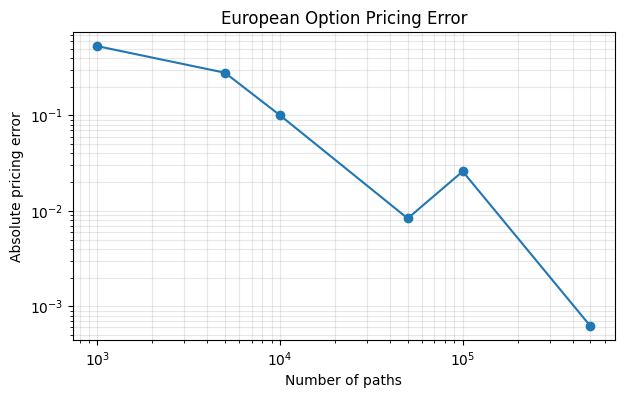

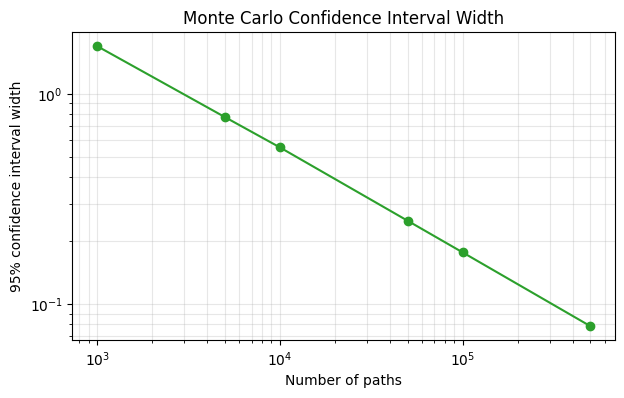

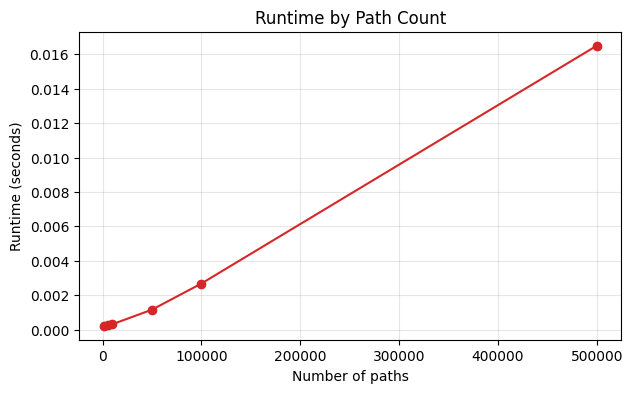

In [4]:
fig_error, fig_ci, fig_runtime = plot_convergence(convergence)